# 🧹 Retail Grocery Sales — Data Cleaning & Feature Engineering

**Dataset:** Supermart Grocery Sales - Retail Analytics Dataset

### Objective
Clean and standardize the raw retail transaction data using **Pandas**, handle data-quality issues, engineer useful features, and export the final dataset as `clean_dataset.csv`.

### Required implementation
- Load raw data into Pandas
- Check and handle missing values
- Detect and handle duplicates, incorrect data types, and outliers
- Extract month/year from the order date
- Calculate profit margin
- Export the cleaned dataset
- Show before/after evidence


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load the data set

In [6]:
# B# Load the raw dataset
df = pd.read_csv("Supermart Grocery Sales - Retail Analytics Dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())


Dataset loaded successfully!
Shape: (9994, 11)


,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


## 2. Understand the data set

In [7]:
# Display number of rows and columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())


Rows: 9994
Columns: 11

Column Names:
['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City', 'Order Date', 'Region', 'Sales', 'Discount', 'Profit', 'State']


## 3. Check Dataset Information

In [8]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Customer Name  9994 non-null   object 
 2   Category       9994 non-null   object 
 3   Sub Category   9994 non-null   object 
 4   City           9994 non-null   object 
 5   Order Date     9994 non-null   object 
 6   Region         9994 non-null   object 
 7   Sales          9994 non-null   int64  
 8   Discount       9994 non-null   float64
 9   Profit         9994 non-null   float64
 10  State          9994 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 859.0+ KB


## 4. Display Statistical Summary

In [10]:
# Statistical summary of numerical columns
display(df.describe())

,Sales,Discount,Profit
count,9994.000000,9994.000000,9994.000000
mean,1496.596158,0.226817,374.937082
std,577.559036,0.074636,239.932881
min,500.000000,0.100000,25.250000
25%,1000.000000,0.160000,180.022500
50%,1498.000000,0.230000,320.780000
75%,1994.750000,0.290000,525.627500
max,2500.000000,0.350000,1120.950000


## 5. Check Missing Values

In [11]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values)

Missing values in each column:


Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64

## 6. Handle Missing Values

In [12]:
# Handle missing values

# Numerical columns → fill with median
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# Categorical columns → fill with mode
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    if df[column].isnull().any():
        df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values handled successfully!")

display(df.isnull().sum())

Missing values handled successfully!


Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64

## 7. Check Duplicate Records

In [13]:
# Check duplicate rows
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


## 8. Remove Duplicate Records

In [14]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Duplicates removed successfully!")
print("New shape:", df.shape)

Duplicates removed successfully!
New shape: (9994, 11)


## 9. Clean text columns

In [15]:
# Clean unnecessary spaces from text columns

text_columns = df.select_dtypes(include="object").columns

for column in text_columns:
    df[column] = df[column].str.strip()

print("Text columns cleaned successfully!")

Text columns cleaned successfully!


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Supermart Grocery Sales - Retail Analytics Dataset.csv")

print("Dataset reloaded!")
print("Shape:", df.shape)

display(df[["Order Date"]].head(20))

Dataset reloaded!
Shape: (9994, 11)


,Order Date
0,11-08-2017
1,11-08-2017
2,06-12-2017
3,10-11-2016
4,10-11-2016
5,06-09-2015
6,06-09-2015
7,06-09-2015
8,06-09-2015
9,06-09-2015


## 10. Convert Order Date to DateTime

In [29]:
# Clean Order Date column
df["Order Date"] = df["Order Date"].astype(str).str.strip()

# Convert dates based on their separator
df["Order Date"] = df["Order Date"].apply(
    lambda x: pd.to_datetime(x, format="%d-%m-%Y", errors="coerce")
    if "-" in x
    else pd.to_datetime(x, format="%m/%d/%Y", errors="coerce")
)

print("Date conversion completed!")

Date conversion completed!


## 11. Check for incorrect dates

In [30]:
print("Date datatype:", df["Order Date"].dtype)
print("Invalid dates:", df["Order Date"].isna().sum())

display(df[["Order Date"]].head(20))

Date datatype: datetime64[ns]
Invalid dates: 0


,Order Date
0,2017-08-11
1,2017-08-11
2,2017-12-06
3,2016-11-10
4,2016-11-10
5,2015-09-06
6,2015-09-06
7,2015-09-06
8,2015-09-06
9,2015-09-06


In [31]:
# Check numeric columns

print("Sales datatype:", df["Sales"].dtype)
print("Discount datatype:", df["Discount"].dtype)
print("Profit datatype:", df["Profit"].dtype)

Sales datatype: int64
Discount datatype: float64
Profit datatype: float64


In [32]:
# Convert numeric columns to appropriate numeric data types

df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
df["Discount"] = pd.to_numeric(df["Discount"], errors="coerce")
df["Profit"] = pd.to_numeric(df["Profit"], errors="coerce")

print("Numeric columns standardized successfully!")

Numeric columns standardized successfully!


## 2. Detect Outliers

The **IQR (Interquartile Range)** method is used to identify extreme numeric values.

- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

Outliers are not automatically deleted because they may represent legitimate high-value transactions. Here, extreme `Profit` values are capped at the IQR upper bound to reduce their influence while retaining all transactions.


In [34]:
# Function to identify outliers using IQR

def find_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_limit) |
        (data[column] > upper_limit)
    ]
    
    return outliers, lower_limit, upper_limit

In [37]:
### Find sales outliers
sales_outliers, sales_lower, sales_upper = find_outliers(df, "Sales")

print("Sales lower limit:", sales_lower)
print("Sales upper limit:", sales_upper)
print("Number of Sales outliers:", len(sales_outliers))

Sales lower limit: -492.125
Sales upper limit: 3486.875
Number of Sales outliers: 0


In [38]:
### Find profit outliers
profit_outliers, profit_lower, profit_upper = find_outliers(df, "Profit")

print("Profit lower limit:", profit_lower)
print("Profit upper limit:", profit_upper)
print("Number of Profit outliers:", len(profit_outliers))

Profit lower limit: -338.385
Profit upper limit: 1044.035
Number of Profit outliers: 43


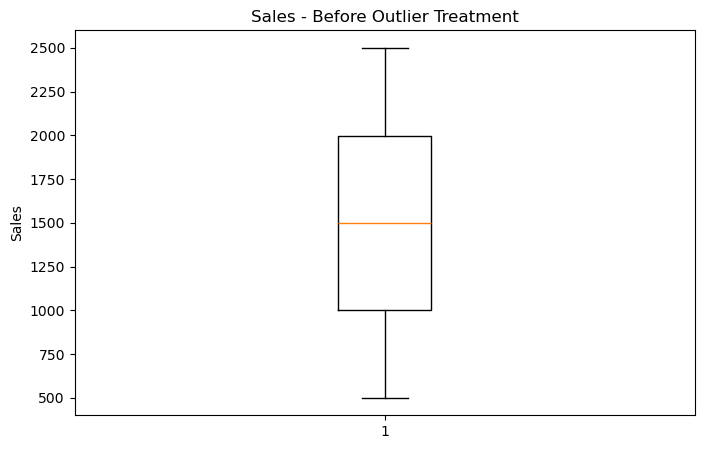

In [39]:
## Visualize Outliers Before Cleaning
plt.figure(figsize=(8, 5))

plt.boxplot(df["Sales"].dropna())

plt.title("Sales - Before Outlier Treatment")
plt.ylabel("Sales")

plt.show()

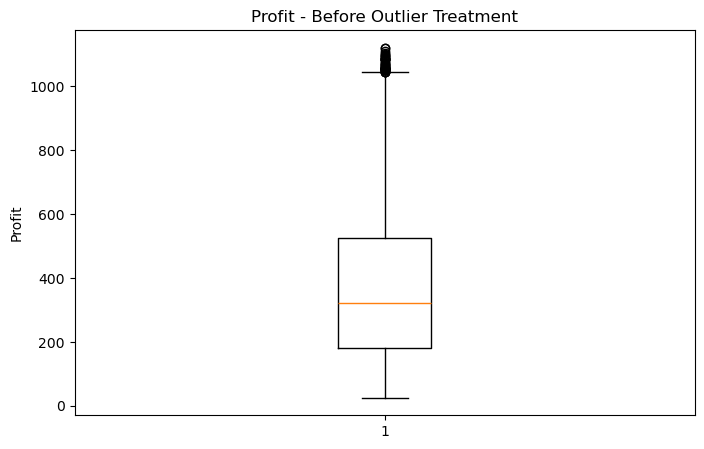

In [40]:
plt.figure(figsize=(8, 5))

plt.boxplot(df["Profit"].dropna())

plt.title("Profit - Before Outlier Treatment")
plt.ylabel("Profit")

plt.show()

In [41]:
# Function to cap outliers using IQR
## Handle outliers
def cap_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    data[column] = data[column].clip(
        lower=lower_limit,
        upper=upper_limit
    )
    
    return data

In [42]:
# Handle outliers in Sales and Profit

df = cap_outliers(df, "Sales")
df = cap_outliers(df, "Profit")

print("Outliers handled successfully!")

Outliers handled successfully!


In [43]:
# Check Sales outliers after treatment

sales_outliers_after, _, _ = find_outliers(df, "Sales")

print("Sales outliers after cleaning:", len(sales_outliers_after))

Sales outliers after cleaning: 0


In [44]:
# Check Profit outliers after treatment

profit_outliers_after, _, _ = find_outliers(df, "Profit")

print("Profit outliers after cleaning:", len(profit_outliers_after))

Profit outliers after cleaning: 0


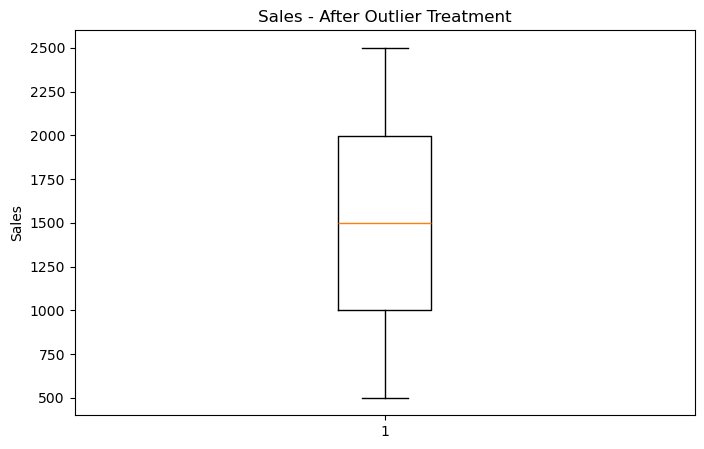

In [45]:
## Visualize After Cleaning
plt.figure(figsize=(8, 5))

plt.boxplot(df["Sales"].dropna())

plt.title("Sales - After Outlier Treatment")
plt.ylabel("Sales")

plt.show()

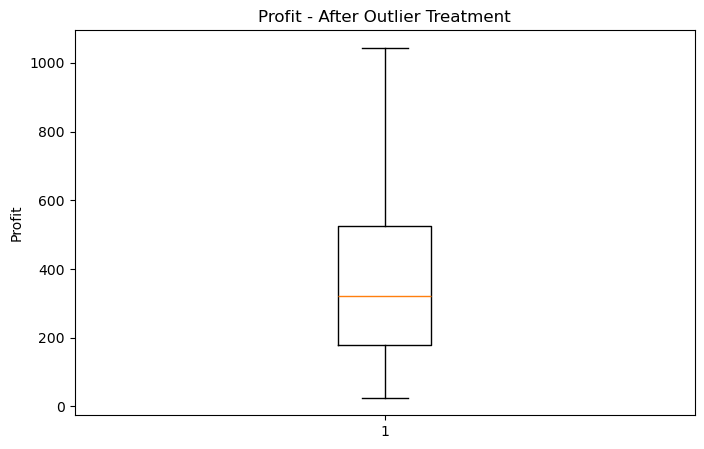

In [46]:
plt.figure(figsize=(8, 5))

plt.boxplot(df["Profit"].dropna())

plt.title("Profit - After Outlier Treatment")
plt.ylabel("Profit")

plt.show()

## 3. Feature Engineering

In [47]:
# Extract year from Order Date

df["Year"] = df["Order Date"].dt.year

display(df[["Order Date", "Year"]].head())

,Order Date,Year
0,2017-08-11,2017
1,2017-08-11,2017
2,2017-12-06,2017
3,2016-11-10,2016
4,2016-11-10,2016


In [48]:
# Extract month number

df["Month"] = df["Order Date"].dt.month

display(df[["Order Date", "Month"]].head())

,Order Date,Month
0,2017-08-11,8
1,2017-08-11,8
2,2017-12-06,12
3,2016-11-10,11
4,2016-11-10,11


In [49]:
# Extract month name

df["Month_Name"] = df["Order Date"].dt.month_name()

display(df[["Order Date", "Month", "Month_Name"]].head())

,Order Date,Month,Month_Name
0,2017-08-11,8,August
1,2017-08-11,8,August
2,2017-12-06,12,December
3,2016-11-10,11,November
4,2016-11-10,11,November


## Calculate Profit Margin
The formula is:
Profit Margin = Profit / Sales × 100

In [50]:
# Calculate Profit Margin

df["Profit_Margin_%"] = np.where(
    df["Sales"] != 0,
    (df["Profit"] / df["Sales"]) * 100,
    0
)

display(
    df[["Sales", "Profit", "Profit_Margin_%"]].head()
)

,Sales,Profit,Profit_Margin_%
0,1254,401.28,32.0
1,749,149.80,20.0
2,2360,165.20,7.0
3,896,89.60,10.0
4,2355,918.45,39.0


In [51]:
# Round profit margin to 2 decimal places

df["Profit_Margin_%"] = df["Profit_Margin_%"].round(2)

display(df[["Sales", "Profit", "Profit_Margin_%"]].head())

,Sales,Profit,Profit_Margin_%
0,1254,401.28,32.0
1,749,149.80,20.0
2,2360,165.20,7.0
3,896,89.60,10.0
4,2355,918.45,39.0


In [53]:
print("Final Dataset Shape:", df.shape)

print("\nFinal Columns:")
print(df.columns.tolist())

print("\nFinal Data Types:")
print(df.dtypes)

Final Dataset Shape: (9994, 15)

Final Columns:
['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City', 'Order Date', 'Region', 'Sales', 'Discount', 'Profit', 'State', 'Year', 'Month', 'Month_Name', 'Profit_Margin_%']

Final Data Types:
Order ID                   object
Customer Name              object
Category                   object
Sub Category               object
City                       object
Order Date         datetime64[ns]
Region                     object
Sales                       int64
Discount                  float64
Profit                    float64
State                      object
Year                        int32
Month                       int32
Month_Name                 object
Profit_Margin_%           float64
dtype: object


In [54]:
# Final missing value check

print("Final Missing Values:")

display(df.isnull().sum())

Final Missing Values:


Order ID           0
Customer Name      0
Category           0
Sub Category       0
City               0
Order Date         0
Region             0
Sales              0
Discount           0
Profit             0
State              0
Year               0
Month              0
Month_Name         0
Profit_Margin_%    0
dtype: int64

In [55]:
# Final duplicate check

print("Final duplicate rows:", df.duplicated().sum())

Final duplicate rows: 0


In [56]:
print("========== DATA CLEANING SUMMARY ==========")

print("Final number of rows:", df.shape[0])
print("Final number of columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nOrder Date datatype:")
print(df["Order Date"].dtype)

print("\nNew Features:")
print("Year")
print("Month")
print("Month_Name")
print("Profit_Margin_%")

========== DATA CLEANING SUMMARY ==========
Final number of rows: 9994
Final number of columns: 15

Missing values:
0

Duplicate rows:
0

Order Date datatype:
datetime64[ns]

New Features:
Year
Month
Month_Name
Profit_Margin_%


In [57]:
display(df.head(10))

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State,Year,Month,Month_Name,Profit_Margin_%
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-08-11,North,1254,0.12,401.28,Tamil Nadu,2017,8,August,32.0
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-08-11,South,749,0.18,149.80,Tamil Nadu,2017,8,August,20.0
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-12-06,West,2360,0.21,165.20,Tamil Nadu,2017,12,December,7.0
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,2016-11-10,South,896,0.25,89.60,Tamil Nadu,2016,11,November,10.0
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,2016-11-10,South,2355,0.26,918.45,Tamil Nadu,2016,11,November,39.0
5,OD6,Adavan,Food Grains,Organic Staples,Dharmapuri,2015-09-06,West,2305,0.26,322.70,Tamil Nadu,2015,9,September,14.0
6,OD7,Jonas,Fruits & Veggies,Fresh Vegetables,Trichy,2015-09-06,West,826,0.33,346.92,Tamil Nadu,2015,9,September,42.0
7,OD8,Hafiz,Fruits & Veggies,Fresh Fruits,Ramanadhapuram,2015-09-06,West,1847,0.32,147.76,Tamil Nadu,2015,9,September,8.0
8,OD9,Hafiz,Bakery,Biscuits,Tirunelveli,2015-09-06,West,791,0.23,181.93,Tamil Nadu,2015,9,September,23.0
9,OD10,Krithika,Bakery,Cakes,Chennai,2015-09-06,West,1795,0.27,484.65,Tamil Nadu,2015,9,September,27.0


## 6. Export Clean Dataset

The cleaned and feature-engineered data is exported as **`clean_dataset.csv`**.

In [58]:
# Export cleaned dataset

df.to_csv("clean_dataset.csv", index=False)

print("Clean dataset exported successfully!")
print("File name: clean_dataset.csv")


Clean dataset exported successfully!
File name: clean_dataset.csv


In [59]:
# Load the exported CSV to verify it

clean_df = pd.read_csv("clean_dataset.csv")

print("Clean CSV loaded successfully!")
print("Shape:", clean_df.shape)

display(clean_df.head())

Clean CSV loaded successfully!
Shape: (9994, 15)


,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State,Year,Month,Month_Name,Profit_Margin_%
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-08-11,North,1254,0.12,401.28,Tamil Nadu,2017,8,August,32.0
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-08-11,South,749,0.18,149.80,Tamil Nadu,2017,8,August,20.0
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-12-06,West,2360,0.21,165.20,Tamil Nadu,2017,12,December,7.0
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,2016-11-10,South,896,0.25,89.60,Tamil Nadu,2016,11,November,10.0
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,2016-11-10,South,2355,0.26,918.45,Tamil Nadu,2016,11,November,39.0


## ✅ Final Result

The final dataset contains standardized text and numeric fields, a properly parsed `Order Date`, extracted `Year`, `Month`, and `Month_Name`, and a calculated `Profit_Margin_%`.

**Output file:** `clean_dataset.csv`
